In [1]:
# 1) Imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [2]:
# 2) Find project root
from pathlib import Path

def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)

    for p in [start, *start.parents]:
        if (
            (p / "1_data" / "trump_tweets_dataset.csv").exists()
            and
            (p / "1_data" / "sp500_history.csv").exists()
        ):
            return p

    raise FileNotFoundError(
        "Project folder not found. Expected: 1_data/trump_tweets_dataset.csv and 1_data/sp500_history.csv"
    )

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "1_data"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)

PROJECT_ROOT: C:\Users\ChristophSchilling\OneDrive - BLAID GmbH\Dokumente\GitHub\trump-tweets-nlp
DATA_DIR: C:\Users\ChristophSchilling\OneDrive - BLAID GmbH\Dokumente\GitHub\trump-tweets-nlp\1_data


In [3]:
# 3) Load the data
tweets = pd.read_csv(DATA_DIR / "trump_tweets_dataset.csv")
sp500 = pd.read_csv(DATA_DIR / "sp500_history.csv")

print("tweets shape:", tweets.shape)
print("sp500 shape:", sp500.shape)

tweets shape: (90554, 18)
sp500 shape: (4529, 6)


In [4]:
# 4) First inspection
display(tweets.head())
display(sp500.head())

print("\nTweets columns:")
print(tweets.columns.tolist())

print("\nSP500 columns:")
print(sp500.columns.tolist())

print("\nTweets info:")
tweets.info()

print("\nSP500 info:")
sp500.info()

,id,date,platform,handle,text,favorite_count,repost_count,quote_flag,repost_flag,deleted_flag,word_count,hashtags,urls,user_mentions,media_count,media_urls,post_url,in_reply_to
0,115859532176676320,2026-01-08T07:42:42-05:00,Truth Social,realDonaldTrump,Arrest them all. They are criminals!!! \nForeign ATM? Somali cash exodus from Minneapolis exponentially larger than other major US airports: https:// justthenews.com/government/sec urity/foreign-a...,11,2,False,False,False,23,NaN,https://justthenews.com/government/security/foreign-atm-somali-cash-exodus-minneapolis-exponentially-larger-other-major-us,NaN,0,NaN,https://truthsocial.com/@realDonaldTrump/posts/115859532176676320,NaN
1,115857498674115807,2026-01-07T23:05:33-05:00,Truth Social,realDonaldTrump,"When a vehicle is coming at you and is being used as a weapon, deadly force is justified, Nicole Parker says: https://www. foxnews.com/video/638738936911 2",55,11,False,False,False,24,NaN,https://www.foxnews.com/video/6387389369112,NaN,0,NaN,https://truthsocial.com/@realDonaldTrump/posts/115857498674115807,NaN
2,115856506155736586,2026-01-07T18:53:08-05:00,Truth Social,realDonaldTrump,"It was a Great Honor to speak with the President of Colombia, Gustavo Petro, who called to explain the situation of drugs and other disagreements that we have had. I appreciated his call and tone,...",19,6,False,False,False,73,NaN,NaN,NaN,0,NaN,https://truthsocial.com/@realDonaldTrump/posts/115856506155736586,NaN
3,115856078669121098,2026-01-07T17:04:26-05:00,Truth Social,realDonaldTrump,"I have just been informed that Venezuela is going to be purchasing ONLY American Made Products, with the money they receive from our new Oil Deal. These purchases will include, among other things,...",565,155,False,False,False,97,NaN,NaN,NaN,0,NaN,https://truthsocial.com/@realDonaldTrump/posts/115856078669121098,NaN
4,115855894695940909,2026-01-07T16:17:38-05:00,Truth Social,realDonaldTrump,"After long and difficult negotiations with Senators, Congressmen, Secretaries, and other Political Representatives, I have determined that, for the Good of our Country, especially in these very tr...",16,7,False,False,False,209,NaN,NaN,NaN,0,NaN,https://truthsocial.com/@realDonaldTrump/posts/115855894695940909,NaN


,Date,Close,High,Low,Open,Volume
0,2008-04-07,1372.54,1386.74,1369.02,1373.69,3747780000
1,2008-04-08,1365.54,1370.16,1360.62,1370.16,3602500000
2,2008-04-09,1354.49,1368.39,1349.97,1365.50,3556670000
3,2008-04-10,1360.55,1367.24,1350.11,1355.37,3686150000
4,2008-04-11,1332.83,1357.98,1331.21,1357.98,3723790000



Tweets columns:
['id', 'date', 'platform', 'handle', 'text', 'favorite_count', 'repost_count', 'quote_flag', 'repost_flag', 'deleted_flag', 'word_count', 'hashtags', 'urls', 'user_mentions', 'media_count', 'media_urls', 'post_url', 'in_reply_to']

SP500 columns:
['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

Tweets info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90554 entries, 0 to 90553
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              90554 non-null  int64 
 1   date            90554 non-null  object
 2   platform        90554 non-null  object
 3   handle          90554 non-null  object
 4   text            90551 non-null  object
 5   favorite_count  90554 non-null  int64 
 6   repost_count    90554 non-null  int64 
 7   quote_flag      90554 non-null  bool  
 8   repost_flag     90554 non-null  bool  
 9   deleted_flag    90554 non-null  bool  
 10  word_count      90554 non-nul

In [5]:
# 5) Standardize column names
tweets.columns = (
    tweets.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

sp500.columns = (
    sp500.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print(tweets.columns.tolist())
print(sp500.columns.tolist())

['id', 'date', 'platform', 'handle', 'text', 'favorite_count', 'repost_count', 'quote_flag', 'repost_flag', 'deleted_flag', 'word_count', 'hashtags', 'urls', 'user_mentions', 'media_count', 'media_urls', 'post_url', 'in_reply_to']
['date', 'close', 'high', 'low', 'open', 'volume']


In [6]:
# 6) Parse date columns
tweets["date"] = pd.to_datetime(tweets["date"], errors="coerce", utc=True)
sp500["date"] = pd.to_datetime(sp500["date"], errors="coerce")

tweets["date_et"] = tweets["date"].dt.tz_convert("US/Eastern")
tweets["post_date"] = tweets["date_et"].dt.date
tweets["post_date"] = pd.to_datetime(tweets["post_date"])

print("Tweet date range:", tweets["post_date"].min(), "->", tweets["post_date"].max())
print("SP500 date range:", sp500["date"].min(), "->", sp500["date"].max())

Tweet date range: 2009-05-04 00:00:00 -> 2026-01-08 00:00:00
SP500 date range: 2008-04-07 00:00:00 -> 2026-04-07 00:00:00


In [7]:
# 7) Basic cleaning
# Cleans the text field, removes unusable empty-text rows, builds a simple engagement measure, fixes boolean columns, and sorts both datasets.
tweets["text"] = tweets["text"].fillna("").astype(str).str.strip()

# Remove empty texts
tweets = tweets[tweets["text"] != ""].copy()

# Create engagement feature
tweets["engagement"] = tweets["favorite_count"].fillna(0) + tweets["repost_count"].fillna(0)

# Ensure boolean columns
bool_cols = ["quote_flag", "repost_flag", "deleted_flag"]
for col in bool_cols:
    if col in tweets.columns:
        tweets[col] = tweets[col].fillna(False).astype(bool)

# Sort both datasets by date
tweets = tweets.sort_values("date").reset_index(drop=True)
sp500 = sp500.sort_values("date").reset_index(drop=True)

print("Tweets after cleaning:", tweets.shape)
print("SP500 after cleaning:", sp500.shape)

Tweets after cleaning: (90551, 21)
SP500 after cleaning: (4529, 6)


In the tweets data set 3 rows that had no usable text got dropped.

In [8]:
# 8) Check missing values
tweet_missing = tweets.isna().sum().sort_values(ascending=False)
sp500_missing = sp500.isna().sum().sort_values(ascending=False)

display(tweet_missing.to_frame("missing_count").head(15))
display(sp500_missing.to_frame("missing_count"))

,missing_count
in_reply_to,86948
media_urls,84714
hashtags,82885
urls,70937
user_mentions,52397
text,0
handle,0
platform,0
date,0
id,0


,missing_count
date,0
close,0
high,0
low,0
open,0
volume,0


Missing values appear in optional metadata fields like in_reply_to, media_urls, hashtags, urls, and user_mentions. This is expected and does not indicate a data quality problem. It mainly means that many posts are not replies and do not contain media, hashtags, links, or mentions.

In [9]:
# 9) Check duplicates
print("Duplicate tweet ids:", tweets["id"].duplicated().sum())
print("Duplicate SP500 dates:", sp500["date"].duplicated().sum())

Duplicate tweet ids: 0
Duplicate SP500 dates: 0


In [10]:
# 10) First content overview
print("Platforms:")
display(tweets["platform"].value_counts(dropna=False).to_frame("count"))

print("Handles:")
display(tweets["handle"].value_counts(dropna=False).head(10).to_frame("count"))

print("Descriptive stats for selected tweet features:")
display(
    tweets[["favorite_count", "repost_count", "word_count", "media_count", "engagement"]]
    .describe()
    .T
)

print("Descriptive stats for market data:")
display(
    sp500[["open", "high", "low", "close", "volume"]]
    .describe()
    .T
)

Platforms:


,count
platform,
Twitter,58851
Truth Social,31700


Handles:


,count
handle,
realDonaldTrump,89372
realDonaldtrump,1179


Descriptive stats for selected tweet features:


,count,mean,std,min,25%,50%,75%,max
favorite_count,90551.0,24294.428863,50187.658458,0.0,40.0,6874.0,25084.0,1905628.0
repost_count,90551.0,6506.997118,10824.063672,0.0,67.0,2672.0,8551.5,398663.0
word_count,90551.0,22.166525,25.924880,1.0,7.0,18.0,24.0,509.0
media_count,90551.0,0.259909,0.543868,0.0,0.0,0.0,0.0,8.0
engagement,90551.0,30801.425981,59191.818205,0.0,187.0,10507.0,32989.0,2233545.0


Descriptive stats for market data:


,count,mean,std,min,25%,50%,75%,max
open,4529.0,2.815318e+03,1.589640e+03,679.28,1.414060e+03,2.365230e+03,3.973590e+03,7.002000e+03
high,4529.0,2.830845e+03,1.596965e+03,695.27,1.420340e+03,2.371540e+03,4.001510e+03,7.002280e+03
low,4529.0,2.798557e+03,1.581613e+03,666.79,1.407100e+03,2.352940e+03,3.943080e+03,6.963460e+03
close,4529.0,2.815806e+03,1.589799e+03,676.53,1.414200e+03,2.363810e+03,3.972610e+03,6.978600e+03
volume,4529.0,4.174595e+09,1.141871e+09,0.00,3.443600e+09,3.920920e+09,4.670770e+09,1.145623e+10


The dataset contains posts from two platforms, with most observations coming from Twitter and a smaller but still substantial share from Truth Social.

The descriptive statistics show that engagement is highly variable, with very large maximum values for both likes and reposts. This suggests a **strongly right-skewed distribution**, where a small number of posts receive exceptionally high attention. Post length also varies considerably, while media_count is low on average, meaning that most posts do not include media.

The market data appears clean and complete. The S&P 500 variables show no obvious structural issues and provide a solid basis for building return and volatility features in the next step.

In [12]:
# 11) Build market features
sp500["simple_return_pct"] = sp500["close"].pct_change()
sp500["log_return"] = np.log(sp500["close"] / sp500["close"].shift(1))

sp500["next_simple_return_pct"] = sp500["simple_return_pct"].shift(-1)
sp500["next_log_return"] = sp500["log_return"].shift(-1)

# Keep an aligned market window for joint EDA
analysis_start = tweets["post_date"].min()
analysis_end = min(tweets["post_date"].max(), sp500["date"].max())

sp500_aligned = sp500[
    (sp500["date"] >= analysis_start) & (sp500["date"] <= analysis_end)
].copy()

print("Analysis window:", analysis_start.date(), "->", analysis_end.date())
display(sp500_aligned.head())

Analysis window: 2009-05-04 -> 2026-01-08


,date,close,high,low,open,volume,simple_return_pct,log_return,next_simple_return_pct,next_log_return
271,2009-05-04,907.24,907.85,879.21,879.21,7038840000,0.033868,0.033307,-0.003792,-0.003799
272,2009-05-05,903.80,907.70,897.34,906.10,6882860000,-0.003792,-0.003799,0.017404,0.017255
273,2009-05-06,919.53,920.28,903.95,903.95,8555040000,0.017404,0.017255,-0.013202,-0.013290
274,2009-05-07,907.39,929.58,901.36,919.58,9120100000,-0.013202,-0.013290,0.024069,0.023784
275,2009-05-08,929.23,930.17,909.03,909.03,8163280000,0.024069,0.023784,-0.021512,-0.021747


In [13]:
# 12) Aggregate posts to daily level (including days without posts)
daily_posts = (
    tweets.groupby("post_date")
    .agg(
        total_posts=("id", "count"),
        total_engagement=("engagement", "sum"),
        avg_engagement=("engagement", "mean"),
        avg_word_count=("word_count", "mean"),
        twitter_posts=("platform", lambda s: (s == "Twitter").sum()),
        truth_social_posts=("platform", lambda s: (s == "Truth Social").sum()),
        quote_posts=("quote_flag", "sum"),
        repost_posts=("repost_flag", "sum"),
        deleted_posts=("deleted_flag", "sum"),
        reply_posts=("in_reply_to", lambda s: s.notna().sum())
    )
    .reset_index()
    .rename(columns={"post_date": "date"})
)

# Expand to a continuous daily timeline
full_dates = pd.DataFrame({
    "date": pd.date_range(
        start=tweets["post_date"].min(),
        end=tweets["post_date"].max(),
        freq="D"
    )
})

daily_posts = full_dates.merge(daily_posts, on="date", how="left")

zero_fill_cols = [
    "total_posts",
    "total_engagement",
    "twitter_posts",
    "truth_social_posts",
    "quote_posts",
    "repost_posts",
    "deleted_posts",
    "reply_posts"
]

daily_posts[zero_fill_cols] = daily_posts[zero_fill_cols].fillna(0)

display(daily_posts.head())
print(daily_posts.shape)

,date,total_posts,total_engagement,avg_engagement,avg_word_count,twitter_posts,truth_social_posts,quote_posts,repost_posts,deleted_posts,reply_posts
0,2009-05-04,2.0,1741.0,870.5,22.5,2.0,0.0,0.0,0.0,0.0,0.0
1,2009-05-05,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
2,2009-05-06,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
3,2009-05-07,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
4,2009-05-08,2.0,83.0,41.5,15.0,2.0,0.0,0.0,0.0,0.0,0.0


(6094, 11)


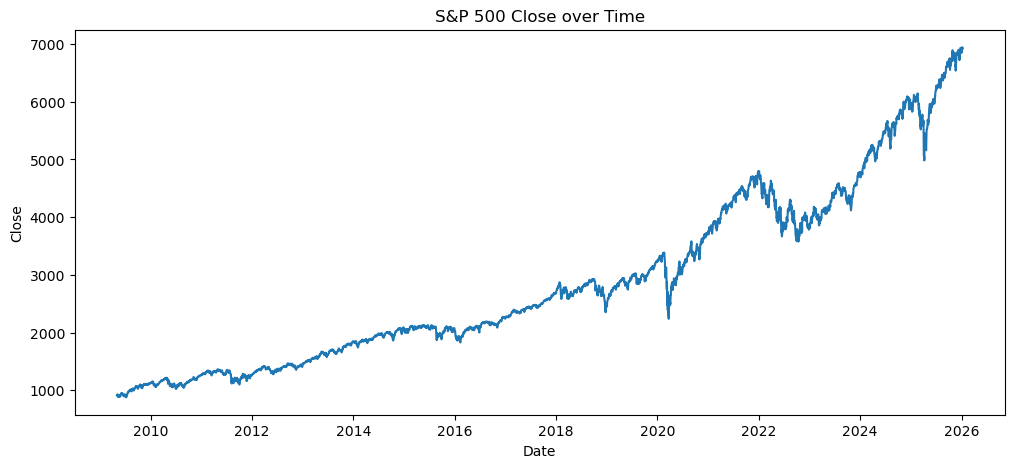

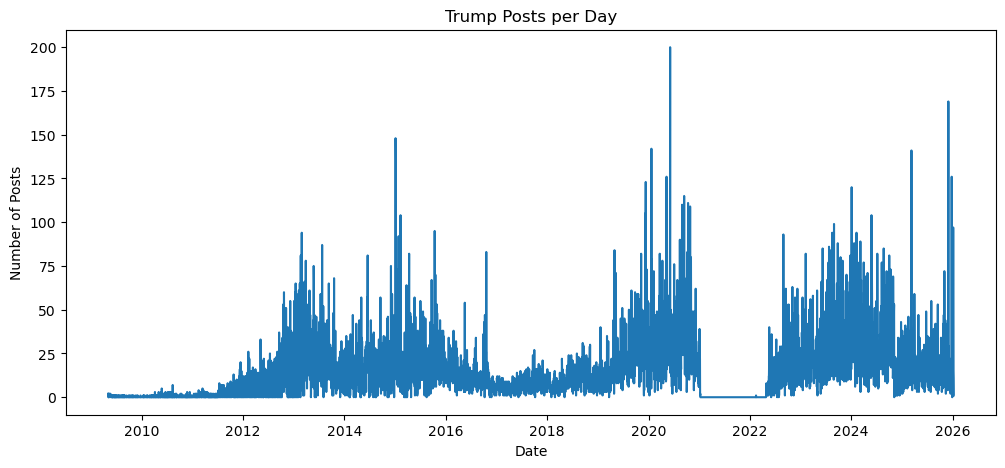

In [14]:
# Qick EDA
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sp500_aligned["date"], sp500_aligned["close"])
ax.set_title("S&P 500 Close over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily_posts["date"], daily_posts["total_posts"])
ax.set_title("Trump Posts per Day")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Posts")
plt.show()

In [15]:
# 11) NLTK setup for tokenization
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer
from nltk import FreqDist

nltk.download("stopwords")
nltk.download("punkt")

stop_words = set(stopwords.words("english"))
tweet_tokenizer = TweetTokenizer(
    preserve_case=False,
    strip_handles=True,
    reduce_len=True
)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ChristophSchilling\AppData\Roaming\nltk_data.
[nltk_data]     ..
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ChristophSchilling\AppData\Roaming\nltk_data.
[nltk_data]     ..
[nltk_data]   Package punkt is already up-to-date!


In [16]:
# 12) Tokenize Trump post text
def tokenize_post(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Normalize common text artifacts
    text = text.replace("&amp;", " and ")
    text = text.replace("#", " ")

    # Tokenize
    tokens = tweet_tokenizer.tokenize(text)

    # Keep alphabetic tokens only and remove stopwords
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words and len(t) > 1]

    return tokens

tweets["tokens"] = tweets["text"].apply(tokenize_post)
tweets["token_count"] = tweets["tokens"].apply(len)
tweets["text_preprocessed"] = tweets["tokens"].apply(" ".join)

display(tweets[["text", "tokens", "token_count"]].head(10))
print("Posts with zero remaining tokens:", (tweets["token_count"] == 0).sum())

,text,tokens,token_count
0,Be sure to tune in and watch Donald Trump on Late Night with David Letterman as he presents the Top Ten List tonight!,"[sure, tune, watch, donald, trump, late, night, david, letterman, presents, top, ten, list, tonight]",14
1,Donald Trump will be appearing on The View tomorrow morning to discuss Celebrity Apprentice and his new book Think Like A Champion!,"[donald, trump, appearing, view, tomorrow, morning, discuss, celebrity, apprentice, new, book, think, like, champion]",14
2,Donald Trump reads Top Ten Financial Tips on Late Show with David Letterman: http://tinyurl.com/ooafwn - Very funny!,"[donald, trump, reads, top, ten, financial, tips, late, show, david, letterman, funny]",12
3,New Blog Post: Celebrity Apprentice Finale and Lessons Learned Along the Way: http://tinyurl.com/qlux5e,"[new, blog, post, celebrity, apprentice, finale, lessons, learned, along, way]",10
4,"""My persona will never be that of a wallflower - I’d rather build walls than cling to them"" --Donald J. Trump","[persona, never, wallflower, rather, build, walls, cling, donald, trump]",9
5,"Miss USA Tara Conner will not be fired - ""I've always been a believer in second chances."" says Donald Trump","[miss, usa, tara, conner, fired, always, believer, second, chances, says, donald, trump]",12
6,"Listen to an interview with Donald Trump discussing his new book, Think Like A Champion: http://tinyurl.com/qs24vl","[listen, interview, donald, trump, discussing, new, book, think, like, champion]",10
7,"""Strive for wholeness and keep your sense of wonder intact."" --Donald J. Trump http://tinyurl.com/pqpfvm","[strive, wholeness, keep, sense, wonder, intact, donald, trump]",8
8,"Enter the ""Think Like A Champion"" signed book and keychain contest: http://www.trumpthinklikeachampion.com/contest/","[enter, think, like, champion, signed, book, keychain, contest]",8
9,"""When the achiever achieves, it's not a plateau, it’s a beginning."" --Donald J. Trump http://tinyurl.com/pqpfvm","[achiever, achieves, plateau, beginning, donald, trump]",6


Posts with zero remaining tokens: 6201


In [17]:
# 13) Most frequent tokens
all_tokens = [token for token_list in tweets["tokens"] for token in token_list]

token_freq = FreqDist(all_tokens)
top_tokens = pd.DataFrame(token_freq.most_common(20), columns=["token", "count"])

display(top_tokens)

,token,count
0,rt,17435
1,trump,13284
2,great,12281
3,president,8903
4,people,6140
5,america,5569
6,thank,5339
7,country,5186
8,new,4675
9,get,4062


In [26]:
# 13b) Remove RT artefact from token lists
# The frequency table above shows that "rt" is not meaningful content,
# but a retweet marker / preprocessing artefact.

tweets["tokens"] = tweets["tokens"].apply(
    lambda token_list: [token for token in token_list if token != "rt"]
)

# if lemmas have already been created at this point, remove "rt" there as well.
if "lemmas" in tweets.columns:
    tweets["lemmas"] = tweets["lemmas"].apply(
        lambda lemma_list: [lemma for lemma in lemma_list if lemma != "rt"]
    )

# Verify removal
all_tokens_cleaned = [
    token
    for token_list in tweets["tokens"]
    for token in token_list
]

token_freq_cleaned = FreqDist(all_tokens_cleaned)
top_tokens_cleaned = pd.DataFrame(
    token_freq_cleaned.most_common(20),
    columns=["token", "count"]
)

display(top_tokens_cleaned)
print("Remaining 'rt' tokens:", token_freq_cleaned["rt"])

,token,count
0,trump,13284
1,great,12281
2,president,8903
3,people,6140
4,america,5569
5,thank,5339
6,country,5186
7,new,4675
8,get,4062
9,would,3992


Remaining 'rt' tokens: 0


In [27]:
# 13) NLTK setup for POS-aware lemmatization
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("averaged_perceptron_tagger_eng")

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ChristophSchilling\AppData\Roaming\nltk_data.
[nltk_data]     ..
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ChristophSchilling\AppData\Roaming\nltk_data.
[nltk_data]     ..
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\ChristophSchilling\AppData\Roaming\nltk_data.
[nltk_data]     ..
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [28]:
# 14) Map POS tags to WordNet format
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    elif treebank_tag.startswith("V"):
        return wordnet.VERB
    elif treebank_tag.startswith("N"):
        return wordnet.NOUN
    elif treebank_tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [29]:
# 15) POS tagging
tweets["pos_tagged"] = tweets["tokens"].apply(pos_tag)

display(tweets[["text", "tokens", "pos_tagged"]].head(10))

,text,tokens,pos_tagged
0,Be sure to tune in and watch Donald Trump on Late Night with David Letterman as he presents the Top Ten List tonight!,"[sure, tune, watch, donald, trump, late, night, david, letterman, presents, top, ten, list, tonight]","[(sure, JJ), (tune, NN), (watch, NN), (donald, NN), (trump, NN), (late, RB), (night, NN), (david, NN), (letterman, NN), (presents, VBZ), (top, JJ), (ten, NNS), (list, NN), (tonight, NN)]"
1,Donald Trump will be appearing on The View tomorrow morning to discuss Celebrity Apprentice and his new book Think Like A Champion!,"[donald, trump, appearing, view, tomorrow, morning, discuss, celebrity, apprentice, new, book, think, like, champion]","[(donald, JJ), (trump, NN), (appearing, VBG), (view, NN), (tomorrow, NN), (morning, NN), (discuss, NN), (celebrity, NN), (apprentice, RB), (new, JJ), (book, NN), (think, VBP), (like, IN), (champio..."
2,Donald Trump reads Top Ten Financial Tips on Late Show with David Letterman: http://tinyurl.com/ooafwn - Very funny!,"[donald, trump, reads, top, ten, financial, tips, late, show, david, letterman, funny]","[(donald, NN), (trump, NN), (reads, VBZ), (top, JJ), (ten, NNS), (financial, JJ), (tips, NNS), (late, RB), (show, VBP), (david, JJ), (letterman, NN), (funny, NN)]"
3,New Blog Post: Celebrity Apprentice Finale and Lessons Learned Along the Way: http://tinyurl.com/qlux5e,"[new, blog, post, celebrity, apprentice, finale, lessons, learned, along, way]","[(new, JJ), (blog, NN), (post, NN), (celebrity, NN), (apprentice, NN), (finale, JJ), (lessons, NNS), (learned, VBD), (along, RP), (way, NN)]"
4,"""My persona will never be that of a wallflower - I’d rather build walls than cling to them"" --Donald J. Trump","[persona, never, wallflower, rather, build, walls, cling, donald, trump]","[(persona, NN), (never, RB), (wallflower, VBP), (rather, RB), (build, JJ), (walls, NNS), (cling, VBG), (donald, NN), (trump, NN)]"
5,"Miss USA Tara Conner will not be fired - ""I've always been a believer in second chances."" says Donald Trump","[miss, usa, tara, conner, fired, always, believer, second, chances, says, donald, trump]","[(miss, JJ), (usa, JJ), (tara, NN), (conner, NN), (fired, VBD), (always, RB), (believer, RB), (second, JJ), (chances, NNS), (says, VBZ), (donald, NN), (trump, NN)]"
6,"Listen to an interview with Donald Trump discussing his new book, Think Like A Champion: http://tinyurl.com/qs24vl","[listen, interview, donald, trump, discussing, new, book, think, like, champion]","[(listen, RB), (interview, NN), (donald, JJ), (trump, NN), (discussing, VBG), (new, JJ), (book, NN), (think, VBP), (like, IN), (champion, NN)]"
7,"""Strive for wholeness and keep your sense of wonder intact."" --Donald J. Trump http://tinyurl.com/pqpfvm","[strive, wholeness, keep, sense, wonder, intact, donald, trump]","[(strive, JJ), (wholeness, NN), (keep, VB), (sense, NN), (wonder, NN), (intact, JJ), (donald, JJ), (trump, NN)]"
8,"Enter the ""Think Like A Champion"" signed book and keychain contest: http://www.trumpthinklikeachampion.com/contest/","[enter, think, like, champion, signed, book, keychain, contest]","[(enter, RB), (think, VBP), (like, IN), (champion, NN), (signed, VBN), (book, NN), (keychain, NN), (contest, NN)]"
9,"""When the achiever achieves, it's not a plateau, it’s a beginning."" --Donald J. Trump http://tinyurl.com/pqpfvm","[achiever, achieves, plateau, beginning, donald, trump]","[(achiever, NN), (achieves, VBZ), (plateau, JJ), (beginning, VBG), (donald, JJ), (trump, NN)]"


In [30]:
# 16) POS-aware lemmatization
def lemmatize_with_pos(tagged_tokens):
    return [
        lemmatizer.lemmatize(token, get_wordnet_pos(tag))
        for token, tag in tagged_tokens
    ]

tweets["lemmas"] = tweets["pos_tagged"].apply(lemmatize_with_pos)
tweets["lemma_count"] = tweets["lemmas"].apply(len)
tweets["text_lemmatized"] = tweets["lemmas"].apply(" ".join)

display(tweets[["text", "tokens", "pos_tagged", "lemmas"]].head(10))

,text,tokens,pos_tagged,lemmas
0,Be sure to tune in and watch Donald Trump on Late Night with David Letterman as he presents the Top Ten List tonight!,"[sure, tune, watch, donald, trump, late, night, david, letterman, presents, top, ten, list, tonight]","[(sure, JJ), (tune, NN), (watch, NN), (donald, NN), (trump, NN), (late, RB), (night, NN), (david, NN), (letterman, NN), (presents, VBZ), (top, JJ), (ten, NNS), (list, NN), (tonight, NN)]","[sure, tune, watch, donald, trump, late, night, david, letterman, present, top, ten, list, tonight]"
1,Donald Trump will be appearing on The View tomorrow morning to discuss Celebrity Apprentice and his new book Think Like A Champion!,"[donald, trump, appearing, view, tomorrow, morning, discuss, celebrity, apprentice, new, book, think, like, champion]","[(donald, JJ), (trump, NN), (appearing, VBG), (view, NN), (tomorrow, NN), (morning, NN), (discuss, NN), (celebrity, NN), (apprentice, RB), (new, JJ), (book, NN), (think, VBP), (like, IN), (champio...","[donald, trump, appear, view, tomorrow, morning, discus, celebrity, apprentice, new, book, think, like, champion]"
2,Donald Trump reads Top Ten Financial Tips on Late Show with David Letterman: http://tinyurl.com/ooafwn - Very funny!,"[donald, trump, reads, top, ten, financial, tips, late, show, david, letterman, funny]","[(donald, NN), (trump, NN), (reads, VBZ), (top, JJ), (ten, NNS), (financial, JJ), (tips, NNS), (late, RB), (show, VBP), (david, JJ), (letterman, NN), (funny, NN)]","[donald, trump, read, top, ten, financial, tip, late, show, david, letterman, funny]"
3,New Blog Post: Celebrity Apprentice Finale and Lessons Learned Along the Way: http://tinyurl.com/qlux5e,"[new, blog, post, celebrity, apprentice, finale, lessons, learned, along, way]","[(new, JJ), (blog, NN), (post, NN), (celebrity, NN), (apprentice, NN), (finale, JJ), (lessons, NNS), (learned, VBD), (along, RP), (way, NN)]","[new, blog, post, celebrity, apprentice, finale, lesson, learn, along, way]"
4,"""My persona will never be that of a wallflower - I’d rather build walls than cling to them"" --Donald J. Trump","[persona, never, wallflower, rather, build, walls, cling, donald, trump]","[(persona, NN), (never, RB), (wallflower, VBP), (rather, RB), (build, JJ), (walls, NNS), (cling, VBG), (donald, NN), (trump, NN)]","[persona, never, wallflower, rather, build, wall, cling, donald, trump]"
5,"Miss USA Tara Conner will not be fired - ""I've always been a believer in second chances."" says Donald Trump","[miss, usa, tara, conner, fired, always, believer, second, chances, says, donald, trump]","[(miss, JJ), (usa, JJ), (tara, NN), (conner, NN), (fired, VBD), (always, RB), (believer, RB), (second, JJ), (chances, NNS), (says, VBZ), (donald, NN), (trump, NN)]","[miss, usa, tara, conner, fire, always, believer, second, chance, say, donald, trump]"
6,"Listen to an interview with Donald Trump discussing his new book, Think Like A Champion: http://tinyurl.com/qs24vl","[listen, interview, donald, trump, discussing, new, book, think, like, champion]","[(listen, RB), (interview, NN), (donald, JJ), (trump, NN), (discussing, VBG), (new, JJ), (book, NN), (think, VBP), (like, IN), (champion, NN)]","[listen, interview, donald, trump, discuss, new, book, think, like, champion]"
7,"""Strive for wholeness and keep your sense of wonder intact."" --Donald J. Trump http://tinyurl.com/pqpfvm","[strive, wholeness, keep, sense, wonder, intact, donald, trump]","[(strive, JJ), (wholeness, NN), (keep, VB), (sense, NN), (wonder, NN), (intact, JJ), (donald, JJ), (trump, NN)]","[strive, wholeness, keep, sense, wonder, intact, donald, trump]"
8,"Enter the ""Think Like A Champion"" signed book and keychain contest: http://www.trumpthinklikeachampion.com/contest/","[enter, think, like, champion, signed, book, keychain, contest]","[(enter, RB), (think, VBP), (like, IN), (champion, NN), (signed, VBN), (book, NN), (keychain, NN), (contest, NN)]","[enter, think, like, champion, sign, book, keychain, contest]"
9,"""Wh

In [31]:
# 17) Most frequent lemmas
all_lemmas = [lemma for lemma_list in tweets["lemmas"] for lemma in lemma_list]

lemma_freq = FreqDist(all_lemmas)
top_lemmas = pd.DataFrame(lemma_freq.most_common(20), columns=["lemma", "count"])

display(top_lemmas)

,lemma,count
0,trump,13343
1,great,13089
2,president,9042
3,get,6826
4,make,6522
5,people,6148
6,go,5966
7,country,5878
8,america,5575
9,state,5478


In [32]:
# Save processed outputs for reuse in other notebooks
OUTPUT_DIR = PROJECT_ROOT / "2_preprocessing" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tweets.to_pickle(OUTPUT_DIR / "tweets_processed.pkl")
daily_posts.to_csv(OUTPUT_DIR / "daily_posts.csv", index=False)
sp500_aligned.to_csv(OUTPUT_DIR / "sp500_aligned.csv", index=False)

print("Saved files to:", OUTPUT_DIR)

Saved files to: C:\Users\ChristophSchilling\OneDrive - BLAID GmbH\Dokumente\GitHub\trump-tweets-nlp\2_preprocessing\processed
